In [ ]:
!pip install --upgrade pip
!pip install -r requirements.txt

In [ ]:
!pip install -q jsonlines peft

In [1]:
import os
import json
import glob
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm

# --- Imports ---
# Since eval.ipynb and eval.py are in the same directory, we can import directly.
# If you run into issues, ensure your current working directory is 'ISRO-GeoNLI-submission'
try:
    from eval import GeoNLIEvaluator, WORD_TO_NUM, clean_id
except ImportError:
    # Fallback if the kernel is running from the parent directory
    sys.path.append('ISRO-GeoNLI-submission')
    from eval import GeoNLIEvaluator, WORD_TO_NUM, clean_id

# --- Dataset Paths ---
# ".." moves up one level to the home directory where jl_fs is located
ANNOTATION_DIR = "../jl_fs/VRS_OBBs/Annotations_oriented"
IMAGE_DIR = "../jl_fs/VRS_OBBs/Images_oriented"
OUTPUT_FILE = "vrs_finetuned_eval_results.json"

# --- Initialize Evaluator (Fixing TypeError) ---
# We instantiate the class and then call .init() manually as per eval.py's structure
evaluator = GeoNLIEvaluator()
evaluator.init(
    model_name='distilbert-base-uncased',
    image_width=512,
    image_height=512,
    batch_size=1
)

# --- Helper Functions ---
def parse_numeric_value(val):
    """Parses a string or number into a float, handling text numbers like 'one'."""
    s_val = str(val).strip().lower()
    if s_val in WORD_TO_NUM:
        return float(WORD_TO_NUM[s_val])
    try:
        # Remove non-numeric chars except period
        clean = "".join(c for c in s_val if c.isdigit() or c == '.')
        return float(clean) if clean else 0.0
    except ValueError:
        return 0.0

def classify_vqa_type(q_type, answer):
    """
    Classifies VQA question into binary, numeric, or semantic 
    using logic consistent with eval.py.
    """
    q_type = str(q_type).lower()
    ans_str = str(answer).strip().lower()
    
    if ('existence' in q_type) or ('yes' in ans_str or 'no' in ans_str):
        return 'binary'
    elif ('quantity' in q_type) or (ans_str.isdigit() or ans_str in WORD_TO_NUM):
        return 'numeric'
    else:
        return 'semantic'

def load_existing_results(filepath):
    """Loads existing JSON results to append to them."""
    if os.path.exists(filepath):
        try:
            with open(filepath, 'r') as f:
                return json.load(f)
        except json.JSONDecodeError:
            return []
    return []

print("Environment configured. Dataset paths set relative to parent directory.")

Initializing GeoNLIEvaluator on cuda...


You are using a model of type distilbert to instantiate a model of type bert. This is not supported for all configurations of models and can yield errors.


Loading weights: 0it [00:00, ?it/s]

BertModel LOAD REPORT from: distilbert-base-uncased
Key                                                                      | Status     | 
-------------------------------------------------------------------------+------------+-
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.out_lin.weight | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.output_layer_norm.bias   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.out_lin.bias   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.ffn.lin2.weight          | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.sa_layer_norm.weight     | UNEXPECTED | 
distilbert.embeddings.word_embeddings.weight                             | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.ffn.lin1.weight          | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.k_lin.bias     | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.

Environment configured. Dataset paths set relative to parent directory.


In [2]:
from rs_pipeline import RSPipeline
pipeline = RSPipeline()

Loading Processor from Base: Qwen/Qwen3-VL-8B-Instruct...
Loading Base Model Weights: Qwen/Qwen3-VL-8B-Instruct...


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

Loading LoRA Adapter: Dinosaur2314/qwen_finetune11...
VLM (Base + Adapter) loaded successfully on cuda
Loading SAM 3: facebook/sam3...
The OrderedVocab you are attempting to save contains holes for indices [1], your vocabulary could be corrupted !
The OrderedVocab you are attempting to save contains holes for indices [1], your vocabulary could be corrupted !


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [3]:
from PIL import Image
import requests
from io import BytesIO

In [4]:
# Import the pipeline processing function
import sys
import os
sys.path.append('scripts')
from run_json_script import process_queries
import json

print("Pipeline processing functions imported! Use process_queries() to run queries.")

Pipeline processing functions imported! Use process_queries() to run queries.


Found 1367 annotation files in ../jl_fs/VRS_OBBs/Annotations_oriented.


Processing Images:   0%|          | 0/1367 [00:00<?, ?it/s]


Processing: P0007_0004


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[Caption Score: 0.8303]
GT: The aerial image, sourced from GoogleEarth with high resolution, shows a parking lot with large vehi...
Pred: This aerial image displays a parking lot adjacent to a road. The lot contains a large number of park...
Ref Exp: "Locate vehicle." | Score: 0.0000 | Found: 10 boxes


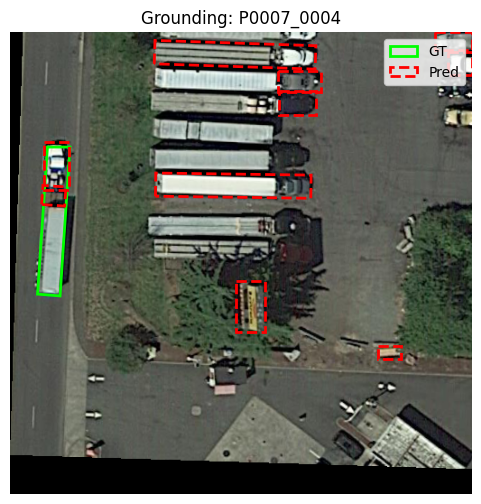

[VQA semantic Score: 1.0000] Q: What is the predominant color of the large vehicles? | A: White (GT: white)
[VQA semantic Score: 0.7443] Q: How are the large vehicles predominantly arranged in the parking lot? | A: Adjacent (GT: in rows)
[VQA binary Score: 1.0000] Q: Are there any large vehicles that are positioned away from the main cluster? | A: Yes (GT: yes)
[VQA binary Score: 0.0000] Q: What is the orientation of the large vehicles in the parking lot? | A: Yes (GT: north-south)

Processing: P0019_0003
[Caption Score: 0.9102]
GT: This high-resolution image provided by GoogleEarth features a natural landscape characterized by a b...
Pred: This aerial image displays a waterfront property. A large body of dark water occupies the right side...
    [Fallback] Skipping invalid box dimensions: 212.0 512 250.0 512
Ref Exp: "Locate ship." | Score: 0.0000 | Found: 0 boxes
    [Qwen Direct] Found 1 objects.
Ref Exp: "Locate harbor." | Score: 0.0000 | Found: 1 boxes


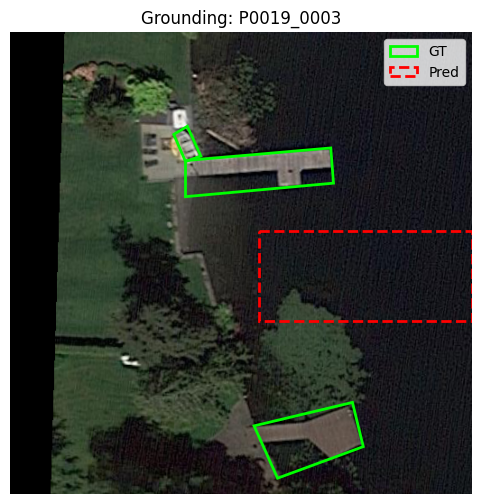

[VQA semantic Score: 0.6996] Q: What is the primary natural feature shown in the image? | A: Water (GT: Body of water)
[VQA numeric Score: 1.0000] Q: How many harbors are visible in the image? | A: 2 (GT: 2)
[VQA semantic Score: 0.9646] Q: Is the small ship closer to the top or bottom of the image? | A: bottom (GT: Top)
[VQA binary Score: 0.0000] Q: Which side of the image has no harbors? | A: Yes (GT: Left side)

Processing: P0019_0054
[Caption Score: 0.8497]
GT: The high-resolution image from GoogleEarth features a small harbor area with adjacent docking facili...
Pred: This aerial image displays a waterfront property at night. A large body of dark water occupies the m...
    [Qwen Direct] Found 1 objects.
Ref Exp: "Locate ship." | Score: 0.0000 | Found: 1 boxes
    [Qwen Direct] Found 1 objects.
Ref Exp: "Locate harbor." | Score: 0.0000 | Found: 1 boxes


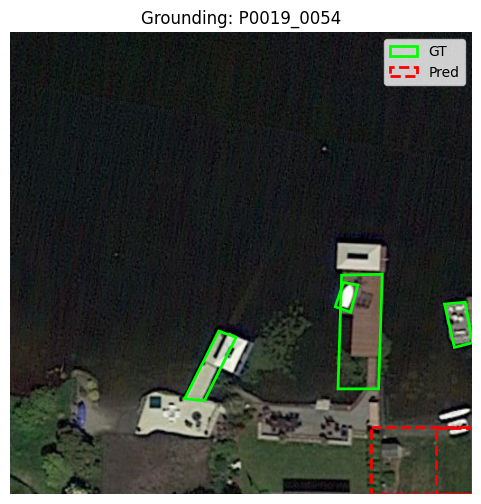

[VQA semantic Score: 0.9696] Q: What is the main structure seen in this satellite image? | A: House (GT: harbor)
[VQA numeric Score: 1.0000] Q: How many ships are clearly visible within the image border? | A: 2 (GT: 2)
[VQA semantic Score: 0.9259] Q: Which object is located to the left-most in the image? | A: left-most (GT: harbor)
[VQA semantic Score: 0.9186] Q: What is the shape of the largest harbor? | A: L-shaped (GT: rectangular)

Processing: P0019_0062
[Caption Score: 0.9677]
GT: This high-resolution image from GoogleEarth shows a waterfront scene with two visible harbors and tw...
Pred: This aerial image captures a waterfront property at night. A large body of dark water occupies the t...
    [Fallback] Skipping invalid box dimensions: 100.0 512 150.0 512
    [Fallback] Skipping invalid box dimensions: 150.0 512 150.0 512
Ref Exp: "Locate ship." | Score: 0.0000 | Found: 0 boxes
    [Qwen Direct] Found 1 objects.
Ref Exp: "Locate harbor." | Score: 0.0000 | Found: 1 boxes


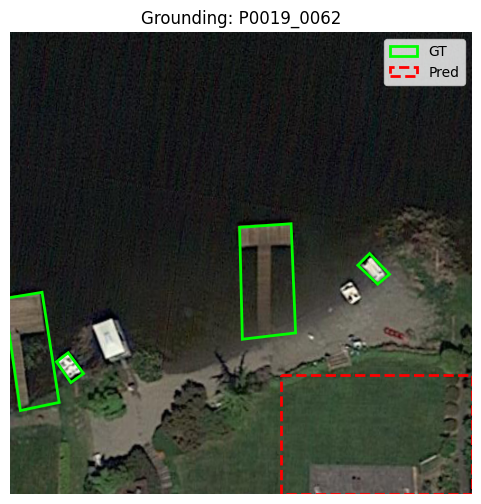

[VQA numeric Score: 1.0000] Q: How many harbors are visible in the image? | A: 2 (GT: 2)
[VQA binary Score: 0.0000] Q: Is there a ship located at the bottom left of the image? | A: No (GT: Yes)
[VQA semantic Score: 0.9623] Q: What is the object category at the bottom-most position on the right side of the image? | A: House (GT: Ship)
[VQA semantic Score: 0.6687] Q: Where is the top-most harbor located in the image? | A: Bottom-left (GT: Center to right)

Processing: P0019_0078
[Caption Score: 0.8407]
GT: The high-resolution image sourced from GoogleEarth depicts a waterfront area with small harbors and ...
Pred: This aerial image displays a waterfront property. A large body of dark water occupies the top portio...
    [Qwen Direct] Found 1 objects.
Ref Exp: "Locate harbor." | Score: 0.0048 | Found: 1 boxes


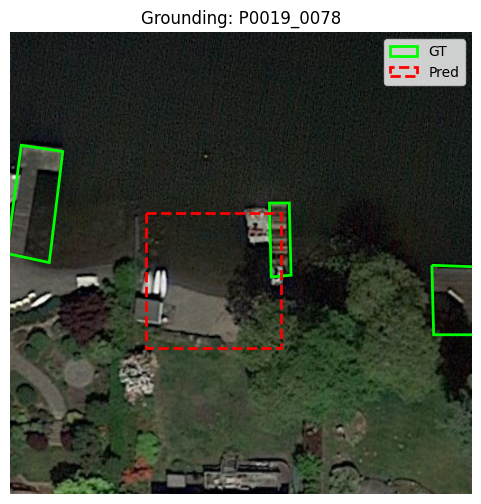

[VQA semantic Score: 0.7505] Q: What is the main structure visible in the image? | A: dock (GT: waterfront area)
[VQA numeric Score: 0.0005] Q: How many harbors are visible? | A: 2 (GT: 3)
[VQA binary Score: 1.0000] Q: Are the ships on the left side of the central harbor mentioned in the description? | A: Yes (GT: Yes)
[VQA semantic Score: 0.9186] Q: What is the shape of the largest harbor? | A: L-shaped (GT: rectangular)
[VQA binary Score: 1.0000] Q: Is there any vegetation near the harbors? | A: Yes (GT: Yes)
[VQA semantic Score: 0.9596] Q: What object is centrally located? | A: Boat (GT: harbor)

Processing: P0019_0081
[Caption Score: 0.9597]
GT: This high-resolution image sourced from GoogleEarth features a maritime setting with vessels and har...
Pred: This aerial image displays a body of dark water bordered by a green, vegetated landmass. Three disti...
    [Qwen Direct] Found 1 objects.
Ref Exp: "Locate ship." | Score: 0.0000 | Found: 1 boxes
    [Fallback] Skipping invalid box 

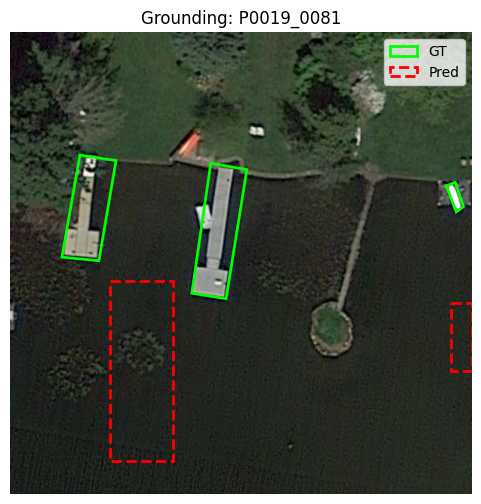

[VQA numeric Score: 0.0000] Q: How many small ships are visible in the image? | A: 2 (GT: 1)
[VQA semantic Score: 0.9603] Q: What type of object is docked on the right side of the image? | A: Boat (GT: ship)
[VQA semantic Score: 0.9384] Q: What objects are found on the left edge and centrally at the bottom in the image? | A: dock (GT: harbors)
[VQA semantic Score: 0.9646] Q: Is the ship located near the top or bottom of the image? | A: bottom (GT: top)

Processing: P0027_0002
[Caption Score: 0.6948]
GT: This is a high-resolution image sourced from GoogleEarth showing a densely vegetated area with a mix...
Pred: This aerial image displays a landscape dominated by a large, dense forest of green trees covering th...
    [Qwen Direct] Found 1 objects.
Ref Exp: "Locate harbor." | Score: 0.0102 | Found: 1 boxes


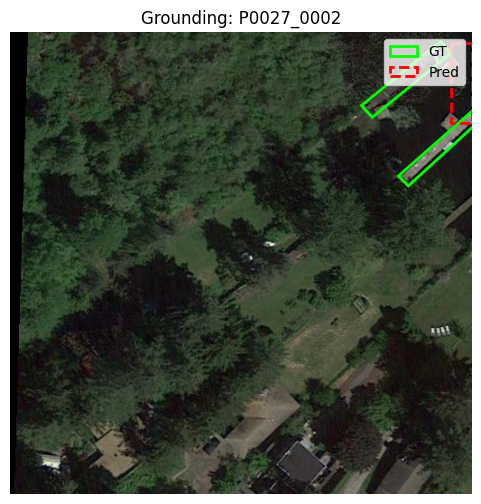

[VQA semantic Score: 0.9247] Q: What type of area does the image primarily depict? | A: Residential (GT: vegetated)
[VQA numeric Score: 0.0000] Q: How many harbors are visible in the image? | A: 0 (GT: 2)
[VQA semantic Score: 0.9646] Q: Is the larger harbor positioned at the top or bottom of the right side? | A: top (GT: bottom)

Processing: P0027_0014
[Caption Score: 0.6311]
GT: The image from GoogleEarth displays a high-resolution view of a harbor located at the bottom of the ...
Pred: This aerial image displays a large, dark body of water occupying most of the frame. In the bottom-ri...
Ref Exp: "Locate harbor." | Score: 0.0064 | Found: 1 boxes


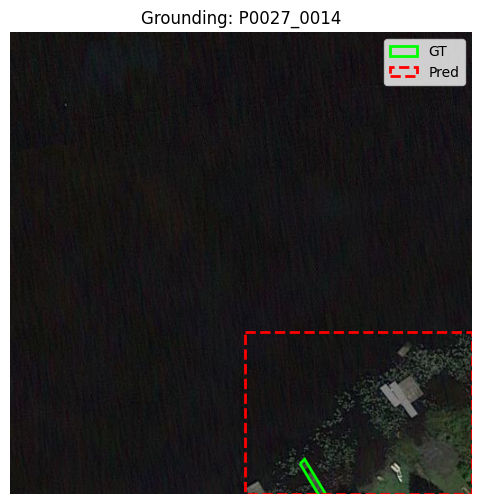

[VQA semantic Score: 0.9596] Q: What object is located at the bottom of the image? | A: Boat (GT: harbor)
[VQA semantic Score: 1.0000] Q: Is the object size large or small? | A: small (GT: small)

Processing: P0047_0000
[Caption Score: 0.7464]
GT: A high-resolution GoogleEarth image showcases a soccer ball field adjacent to a curved path, with a ...
Pred: This aerial image displays a recreational area adjacent to a large body of water. A paved road runs ...
    [Qwen Direct] Found 1 objects.
Ref Exp: "Locate soccer-ball-field." | Score: 0.2059 | Found: 1 boxes
Ref Exp: "Locate vehicle." | Score: 0.0046 | Found: 7 boxes


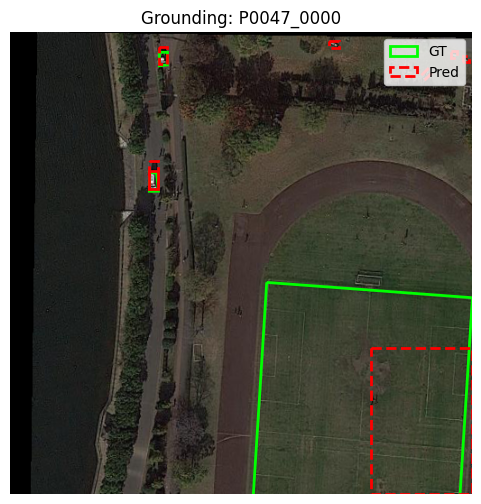

[VQA semantic Score: 0.9264] Q: What type of field is shown in the image? | A: Soccer (GT: soccer-ball-field)
[VQA numeric Score: 0.0000] Q: How many small vehicles are there? | A: 3 (GT: 1)
[VQA binary Score: 1.0000] Q: Is there a large vehicle in the image? | A: Yes (GT: Yes)
[VQA semantic Score: 0.9667] Q: What shape is the path next to the soccer ball field? | A: Oval (GT: Curved)
[VQA semantic Score: 0.6894] Q: Where is the small vehicle located relative to the waterfront? | A: Adjacent (GT: By the waterfront)

Processing: P0104_0003
[Caption Score: 0.8281]
GT: The high-resolution image from GoogleEarth depicts a section of an urban area with roadways, small v...
Pred: This aerial image displays a street intersection with a curved road on the left and a straight road ...
Ref Exp: "Locate vehicle." | Score: 0.0013 | Found: 9 boxes


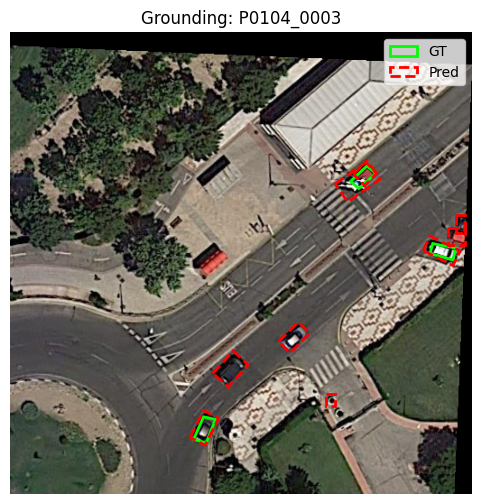

[VQA numeric Score: 1.0000] Q: How many small vehicles are visible in the image? | A: 5 (GT: 5)
[VQA semantic Score: 0.9274] Q: Where is the right-most vehicle located? | A: Adjacent (GT: Middle-right)
[VQA semantic Score: 0.7491] Q: What is the main type of transportation visible in the image? | A: Car (GT: Small vehicles)
[VQA semantic Score: 1.0000] Q: What color are the road markings near the center of the image? | A: White (GT: White)
[VQA semantic Score: 0.7527] Q: Are the vehicles spread out or clustered together? | A: clustered (GT: Spread out)

Processing: P0110_0015
[Caption Score: 0.6833]
GT: The medium-resolution image provided by GoogleEarth shows a sprawling, forested area flanked by a bo...
Pred: This aerial image displays a large, dark-colored barge navigating a wide waterway. The waterway is f...
Ref Exp: "Locate harbor." | Score: 0.8209 | Found: 1 boxes


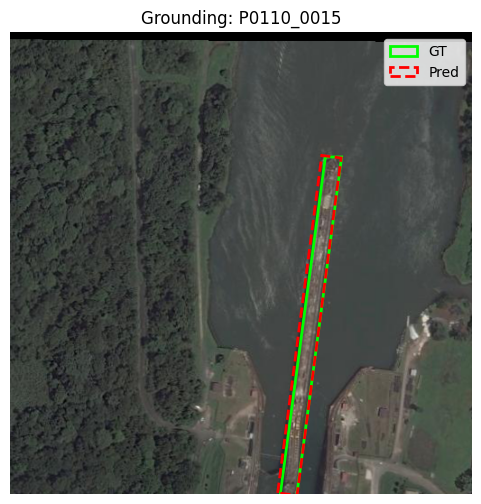

[VQA semantic Score: 0.9618] Q: What is the main structure visible in the image? | A: Dam (GT: harbor)
[VQA semantic Score: 0.9669] Q: What kind of area surrounds the harbor? | A: Forest (GT: forested)
[VQA binary Score: 1.0000] Q: Does the image show man-made structures? | A: Yes (GT: Yes)

Processing: P0117_0004
[Caption Score: 0.8320]
GT: The high-resolution image from GoogleEarth displays a baseball diamond surrounded by vast green fiel...
Pred: This aerial image displays a landscape with a baseball field in the northwest, characterized by its ...
    [Qwen Direct] Found 1 objects.
Ref Exp: "Locate baseball-diamond." | Score: 0.0185 | Found: 1 boxes
Ref Exp: "Locate vehicle." | Score: 0.0002 | Found: 10 boxes


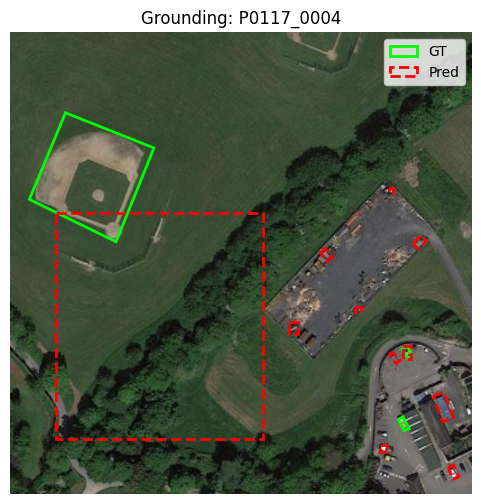

[VQA semantic Score: 0.9816] Q: What sport-related structure is visible in the image? | A: Baseball field (GT: baseball diamond)
[VQA semantic Score: 1.0000] Q: What is the primary color of the fields surrounding the baseball diamond? | A: Green (GT: green)
[VQA binary Score: 1.0000] Q: Are there any large vehicles present in the image? | A: Yes (GT: Yes)
[VQA semantic Score: 0.9602] Q: What is the shape of the baseball diamond? | A: Square (GT: diamond)
[VQA semantic Score: 1.0000] Q: Is the baseball diamond positioned in the upper or lower half of the image? | A: Upper (GT: upper)

Processing: P0143_0000
[Caption Score: 0.8735]
GT: This is a medium resolution image sourced from GoogleEarth featuring a coastal urban environment wit...
Pred: This aerial image displays a coastal area with a large body of dark blue water occupying the norther...
    [Fallback] Skipping invalid box dimensions: 400.0 512 512 512
Ref Exp: "Locate soccer-ball-field." | Score: 0.0000 | Found: 0 boxes
    [Fal

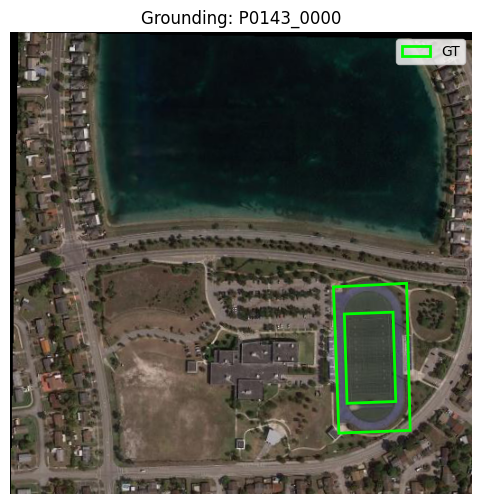

[VQA semantic Score: 1.0000] Q: What is the shape of the soccer-ball field? | A: Oval (GT: Oval)
[VQA semantic Score: 0.9696] Q: What color is the body of water? | A: Blue (GT: Turquoise)
[VQA binary Score: 1.0000] Q: Is there a track surrounding the soccer-ball field? | A: Yes (GT: Yes)
[VQA semantic Score: 1.0000] Q: What is the position of the soccer-ball field relative to the ground-track field? | A: Adjacent (GT: Adjacent)
[VQA binary Score: 1.0000] Q: Are there buildings visible in the image? | A: Yes (GT: Yes)
[VQA semantic Score: 0.9621] Q: What type of area is shown in the image? | A: Coastal (GT: Urban)

Processing: P0175_0002
[Caption Score: 0.9253]
GT: The image from GoogleEarth shows a high-resolution view of an outdoor area with small vehicle and th...
Pred: An aerial view shows three adjacent tennis courts with grey surfaces and white lines, situated on th...
Ref Exp: "Locate vehicle." | Score: 0.5416 | Found: 1 boxes
Ref Exp: "Locate tennis-court." | Score: 0.0717 | Fou

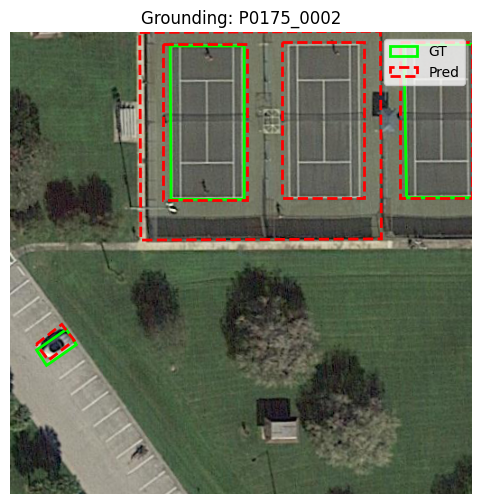

[VQA semantic Score: 0.8273] Q: What are the main objects visible in the image? | A: Tennis courts (GT: Tennis courts, vehicles)
[VQA numeric Score: 1.0000] Q: How many small vehicles can be seen in this image? | A: 1 (GT: One)
[VQA semantic Score: 0.9699] Q: Are the tennis courts arranged vertically or horizontally? | A: horizontally (GT: Vertically)
[VQA semantic Score: 1.0000] Q: Is the image taken from a satellite or aerial perspective? | A: Satellite (GT: Satellite)
[VQA binary Score: 1.0000] Q: Is there a small vehicle near the tennis courts? | A: Yes (GT: Yes)

Processing: P0179_0004


In [ ]:
import matplotlib.patches as patches
import glob

# --- Run Parameters ---
START_INDEX = 0
SAVE_EVERY = 1     

# --- Load Data ---
json_files = sorted(glob.glob(os.path.join(ANNOTATION_DIR, "*.json")))
results_container = load_existing_results(OUTPUT_FILE)
print(f"Found {len(json_files)} annotation files in {ANNOTATION_DIR}.")

# --- Main Loop ---
for idx in tqdm(range(START_INDEX, len(json_files)), desc="Processing Images"):
    gt_file_path = json_files[idx]
    
    # Clean ID
    file_id = clean_id(gt_file_path) 
    
    # Path
    img_path = os.path.join(IMAGE_DIR, f"{file_id}.png")
    if not os.path.exists(img_path):
        continue

    # 1. Load GT
    with open(gt_file_path, 'r') as f:
        gt_data = json.load(f)
    
    # 2. Load Image
    try:
        pil_image = Image.open(img_path).convert("RGB")
        img_w, img_h = pil_image.size
    except Exception as e:
        print(f"Error loading image {img_path}: {e}")
        continue

    img_result = {
        "image_id": file_id,
        "caption": {},
        "grounding": [],
        "vqa": []
    }

    print(f"\n{'='*40}\nProcessing: {file_id}\n{'='*40}")
    
    # --- A. Captioning ---
    if gt_data.get('caption'):
        pred_caption = pipeline.generate_caption(
            image=pil_image,
            instruction="Generate a detailed caption describing all visible elements in the image."
        )
        
        pred_ngrams = evaluator.preprocess_text_to_ngrams([pred_caption])
        ref_ngrams = evaluator.preprocess_text_to_ngrams([gt_data['caption']])
        score = evaluator.batch_bert_bleu_score(pred_ngrams, ref_ngrams)[0]
        
        img_result['caption'] = {
            "pred": pred_caption,
            "gt": gt_data['caption'],
            "score": score
        }
        print(f"[Caption Score: {score:.4f}]\nGT: {gt_data['caption'][:100]}...\nPred: {pred_caption[:100]}...")

    # --- B. Grounding (OBB) ---
    gt_objects = gt_data.get('objects', [])
    unique_classes = set(obj['obj_cls'] for obj in gt_objects)
    
    # Prepare Plot
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(pil_image)
    ax.set_title(f"Grounding: {file_id}")
    ax.axis('off')
    plot_active = False # Flag to show plot only if objects exist

    for obj_cls in unique_classes:
        # REFERRING EXPRESSION
        prompt = f"Locate {obj_cls}."
        
        # Collect GT 
        class_gt_boxes = [obj['obj_corner'] for obj in gt_objects if obj['obj_cls'] == obj_cls]
        
        # PREDICTION
        grounding_results = pipeline.grounding.ground_objects(pil_image, prompt, show_visualization=False)
        
        # Extract pixel boxes from results
        pred_boxes_pixel = [item['obbox'] for item in grounding_results]
        
        # NORMALIZE PREDICTIONS for Evaluator (Pixels -> 0..1)
        pred_boxes_norm = []
        for box in pred_boxes_pixel:
            # box is [x1, y1, x2, y2, x3, y3, x4, y4]
            norm_box = [c / img_w if i % 2 == 0 else c / img_h for i, c in enumerate(box)]
            pred_boxes_norm.append(norm_box)

        # Evaluate
        score = evaluator.evaluate_grounding(pred_boxes_norm, class_gt_boxes, coordinate_system='normalized')
        
        img_result['grounding'].append({
            "class": obj_cls,
            "prompt": prompt,
            "pred": pred_boxes_norm,
            "gt": class_gt_boxes,
            "score": score
        })
        
        # --- MODIFIED PRINT STATEMENT ---
        print(f"Ref Exp: \"{prompt}\" | Score: {score:.4f} | Found: {len(pred_boxes_pixel)} boxes")
        
        # --- VISUALIZATION DRAWING ---
        plot_active = True
        
        # 1. Draw GT (Green)
        for box in class_gt_boxes:
            # Check if GT is normalized or pixels and convert if necessary
            is_gt_normalized = all(x <= 1.5 for x in box) 
            
            flat_coords = box
            if is_gt_normalized:
                flat_coords = [c * img_w if i % 2 == 0 else c * img_h for i, c in enumerate(box)]
            
            poly_coords = list(zip(flat_coords[0::2], flat_coords[1::2]))
            poly = patches.Polygon(poly_coords, linewidth=2, edgecolor='lime', facecolor='none', label='GT')
            ax.add_patch(poly)

        # 2. Draw Pred (Red)
        for box in pred_boxes_pixel:
            poly_coords = list(zip(box[0::2], box[1::2]))
            poly = patches.Polygon(poly_coords, linewidth=2, edgecolor='red', facecolor='none', linestyle='--', label='Pred')
            ax.add_patch(poly)

    if plot_active:
        # Avoid duplicate labels in legend
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), loc='upper right')
        plt.show()
    else:
        plt.close()

    # --- C. VQA ---
    for qa in gt_data.get('qa_pairs', []):
        question = qa['question']
        gt_answer = str(qa['answer'])
        q_type_str = qa.get('type', '')
        
        vqa_type = classify_vqa_type(q_type_str, gt_answer)
        
        pred_answer = pipeline.answer_question(
            image=pil_image,
            query=question,
            question_type=vqa_type
        )
        
        score = 0.0
        if vqa_type == 'binary':
            score = evaluator.evaluate_binary(pred_answer, gt_answer)
        elif vqa_type == 'numeric':
            p_val = parse_numeric_value(pred_answer)
            g_val = parse_numeric_value(gt_answer)
            score = evaluator.evaluate_numeric(p_val, g_val)
        else: # Semantic
            p_gram = evaluator.preprocess_text_to_ngrams([pred_answer])
            r_gram = evaluator.preprocess_text_to_ngrams([gt_answer])
            score = evaluator.batch_bert_bleu_score(p_gram, r_gram)[0]
            
        img_result['vqa'].append({
            "question": question,
            "type": vqa_type,
            "pred": pred_answer,
            "gt": gt_answer,
            "score": score
        })
        print(f"[VQA {vqa_type} Score: {score:.4f}] Q: {question} | A: {pred_answer} (GT: {gt_answer})")

    # Save
    results_container.append(img_result)
    if (idx + 1) % SAVE_EVERY == 0:
        with open(OUTPUT_FILE, 'w') as f:
            json.dump(results_container, f, indent=2)

with open(OUTPUT_FILE, 'w') as f:
    json.dump(results_container, f, indent=2)
print("Processing Complete.")